In [1]:
import os
os.environ['USER_AGENT'] = 'Mozilla/5.0 (Windows NT 6.1; Win64; x64; rv:47.0) Gecko/20100101 Firefox/47.0'
import langchain
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import OpenAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore
import bs4
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langgraph.checkpoint.memory import MemorySaver
langchain.__version__


'0.3.27'

In [2]:
with open("data/secrets/key.secret") as f:
    os.environ["OPENAI_API_KEY"] = f.read()

In [3]:
url = "https://en.wikipedia.org/wiki/Retrieval-augmented_generation"

loader = WebBaseLoader(
    web_paths=(url,),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("mw-body-content",)
        )
    ),
)
docs = loader.load()
docs[0].page_content[:100]

'Type of information retrieval using LLMs\nRetrieval-augmented generation (RAG) is a technique that en'

In [4]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)
len(all_splits)

31

In [5]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = InMemoryVectorStore(embeddings)
db = vector_store.add_documents(documents=all_splits)
len(db)

31

In [6]:
template="""
You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Use {nb} sentences maximum and keep the answer concise.
Question: {question}
Context: {context}
Answer:
"""
prompt = ChatPromptTemplate.from_messages(
    [("user", template)]
)
prompt

ChatPromptTemplate(input_variables=['context', 'nb', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'nb', 'question'], input_types={}, partial_variables={}, template="\nYou are an assistant for question-answering tasks.\nUse the following pieces of retrieved context to answer the question.\nIf you don't know the answer, just say that you don't know.\nUse {nb} sentences maximum and keep the answer concise.\nQuestion: {question}\nContext: {context}\nAnswer:\n"), additional_kwargs={})])

In [7]:
llm = init_chat_model("gpt-4o-mini", model_provider="openai")

class State(TypedDict):
    question: str
    context: List[Document]
    answer: str


# Define application steps
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}

def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content, "nb":3})
    response = llm.invoke(messages)
    return {"answer": response.content}



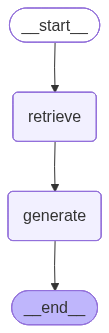

In [8]:
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
graph

In [9]:
config = {"configurable": {"thread_id": "uniqueId1234"}}
response = graph.invoke({"question": "Qu'est ce que le RAG?"}, config=config)
response["answer"]

"Le RAG, ou génération augmentée par récupération, est une technique qui améliore les modèles de langage en incorporant des informations extérieures lors de la génération de réponses. Cela permet aux modèles d'accéder à des données actualisées ou spécifiques à un domaine, en réduisant les hallucinations de l'IA. Grâce à cette approche, les modèles peuvent également citer des sources, offrant ainsi plus de transparence et de vérifiabilité."

In [11]:
response = graph.invoke({"question": "Comment apprend celà?"}, config=config)
response["answer"]

'Pour apprendre cela, on utilise des techniques comme la tâche de cloze inversée (ICT) pour préformer le récupérateur en apprenant des modèles de récupération. Ensuite, l\'optimisation supervisée alinée avec la distribution de probabilité du modèle générateur afin d\'améliorer les performances, et des techniques de reranking pour prioriser les documents les plus pertinents. Enfin, l\'ajout d\'informations récentes dans l\'entrée du modèle (appelé "prompt stuffing") permet de mieux guider les réponses de l\'LLM.'